## VeBNN training with one-dimensional illustrative example

In [12]:
# import packages 
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
from VeBNN.networks.mean_nets import MeanNet
from VeBNN.networks.variance_nets import GammaVarNet
from VeBNN.methods.sgmcmc_trainer import SGMCMCTrainer
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [13]:
# create the one-dimensional Xsin function with noise
def Xsin(x:torch.Tensor, train=False, noise_type: str= "homo") -> torch.Tensor:
    """ Xsin function with noise

    Parameters
    ----------
    x : torch.Tensor
        input tensor of the Xsin function
    train : bool, optional
        generating training or testing data, by default False
    noise_type : str, optional
        define the noise, by default "homo"

    Returns
    -------
    Responses
        responses of the input data points
    """
    if not train:
        return x * torch.sin(x)
    else:
        if noise_type == "heter":
            return x * torch.sin(x) + torch.abs(x) * torch.randn_like(x) * 0.3 + torch.randn_like(x) * 0.3
        elif noise_type == "homo":
            x * torch.sin(x) + torch.randn_like(x) * 0.5

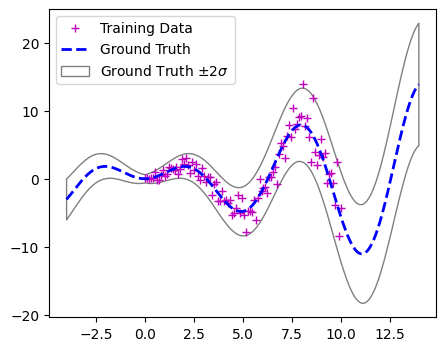

In [14]:
# generate data based on the defined function
samples = torch.linspace(0, 10, 100).reshape(-1, 1)
responses = Xsin(samples, train=True, noise_type="heter")
plot_samples = torch.linspace(-4, 14, 1400).reshape(-1, 1)
ground_truth = Xsin(plot_samples, train=False)


# plot the Xsin function
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(samples, responses, "m+", label="Training Data")
ax.plot(plot_samples, ground_truth,  "b--",
               linewidth=2, label="Ground Truth")
ax.fill_between(
        plot_samples.squeeze(),
        (ground_truth - 2*(torch.abs(plot_samples)*0.3 + 0.3)).squeeze(),
        (ground_truth + 2*(torch.abs(plot_samples)*0.3 + 0.3)).squeeze(),
        color="gray",
        edgecolor="black",
        facecolor="None",
        alpha=0.5,
        label=r"Ground Truth $\pm 2\sigma$",
    )   
plt.legend()
plt.show()

In [15]:
# define the mean and variance networks
mean_mlp = nn.Sequential(
        nn.Linear(1, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        nn.Linear(64, 1),
    )
mean_net = MeanNet(
    net=mean_mlp,
    prior_mu=0.0,
    prior_sigma=1.0,
)
variance_mlp = nn.Sequential(
    nn.Linear(1, 5),
    nn.Tanh(),
    nn.Linear(5, 2 * 1),  
)
var_net = GammaVarNet(
    net=variance_mlp,
    prior_mu=0.0,
    prior_sigma=1.0,
)

In [16]:
# ====== build trainer ======
trainer = SGMCMCTrainer(
    mean_net=mean_net,
    var_net=var_net,
    device=torch.device("cpu"),
    job_id=1,  # any integer; used for temporary folder
)

# ====== configs (kept small so test is fast) ======
init_config = {
    "loss_name": "MSE",
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-6,
    "num_epochs": 2000,      # warm-up epochs
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "split_ratio": 0.8,
}

var_config = {
    "optimizer_name": "Adam",
    "lr": 1e-2,
    "num_epochs": 10000,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 50,
    "early_stopping": False,
    "early_stopping_iter": 100,
    "early_stopping_tol": 1e-4,
}

sampler_config = {
    "sampler": "pSGLD",   # must match your VeBNN.samplers names
    "lr": 1e-3,
    "gamma": 0.9999,
    "num_epochs": 5000,    # SGMCMC epochs
    "mix_epochs": 100,     # thinning interval
    "burn_in_epochs": 1000,
    "batch_size": 64,
    "verbose": True,
    "print_iter": 100,
}

# ====== run cooperative training ======
# iteration controls how many outer loops (var <-> mean) you do.
# For a quick test, iteration=2 is enough to see if everything works.
trainer.cooperative_train(
    x_train=samples,
    y_train=responses,
    iteration=2,
    init_config=init_config,
    var_config=var_config,
    sampler_config=sampler_config,
    delete_model_raw_data=True,  # delete temporary folder after training
)


Epoch 1/2000, Train loss: 1.938e+01, Val loss: 1.146e+01
Epoch 50/2000, Train loss: 1.676e+01, Val loss: 1.154e+01
Epoch 100/2000, Train loss: 1.453e+01, Val loss: 1.224e+01
Epoch 150/2000, Train loss: 1.318e+01, Val loss: 9.458e+00
Epoch 200/2000, Train loss: 1.237e+01, Val loss: 8.831e+00
Epoch 250/2000, Train loss: 1.151e+01, Val loss: 8.508e+00
Epoch 300/2000, Train loss: 1.083e+01, Val loss: 7.226e+00
Epoch 350/2000, Train loss: 1.012e+01, Val loss: 7.272e+00
Epoch 400/2000, Train loss: 9.803e+00, Val loss: 6.886e+00
Epoch 450/2000, Train loss: 9.375e+00, Val loss: 6.974e+00
Epoch 500/2000, Train loss: 9.114e+00, Val loss: 6.547e+00
Epoch 550/2000, Train loss: 8.902e+00, Val loss: 6.090e+00
Epoch 600/2000, Train loss: 8.721e+00, Val loss: 6.107e+00
Epoch 650/2000, Train loss: 8.368e+00, Val loss: 6.124e+00
Epoch 700/2000, Train loss: 7.961e+00, Val loss: 5.150e+00
Epoch 750/2000, Train loss: 7.316e+00, Val loss: 4.727e+00
Epoch 800/2000, Train loss: 6.621e+00, Val loss: 3.992e+00


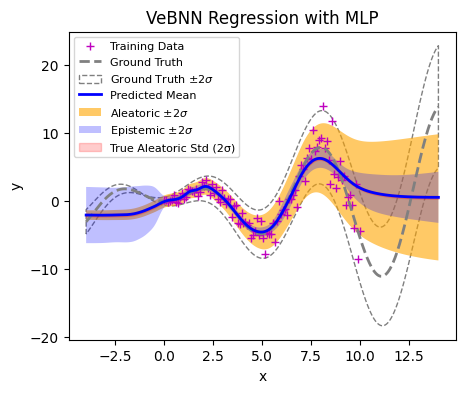

In [24]:
# get prediction for the plot_samples
pred_mean, pred_epistemic_var = trainer.bayes_predict(plot_samples)
pred_aleatoric_var = trainer.aleatoric_variance_predict(plot_samples)

fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(samples, responses, "m+",  label="Training Data")
ax.plot(plot_samples, ground_truth,  "--", color="gray",
               linewidth=2, label="Ground Truth")
# plot ground truth with 2 std
ax.fill_between(
    plot_samples.squeeze(),
    (ground_truth - 2*(0.3+0.3*plot_samples )).squeeze(),
    (ground_truth + 2*(0.3+0.3*plot_samples)).squeeze(),
    color="gray",
    edgecolor="black",
    facecolor="None",
    linestyle="--",
    alpha=0.5,
    label=r"Ground Truth $\pm 2\sigma$",
)
# plot the prediction
ax.plot(plot_samples, pred_mean, color="b",
            linewidth=2,  label="Predicted Mean")
# plot the Aleatoric uncertainty
ax.fill_between(
    plot_samples.squeeze(),
    (pred_mean - 2*pred_aleatoric_var**0.5).squeeze(),
    (pred_mean + 2*pred_aleatoric_var**0.5).squeeze(),
    color="orange",
    alpha=0.6,
    edgecolor="None",
    label=r"Aleatoric $\pm 2\sigma$",

)
# plot the Epistemic uncertainty
ax.fill_between(
    plot_samples.squeeze(),
    (pred_mean - 2*pred_epistemic_var**0.5).squeeze(),
    (pred_mean + 2*pred_epistemic_var**0.5).squeeze(),
    color="blue",
    alpha=0.25,
    edgecolor="None",
    label=r"Epistemic $\pm 2\sigma$",

)
# plot the ground truth of aleatoric noise
y_true_ale_var = 0.1**2 * torch.ones_like(plot_samples)
y_true_ale_std = torch.sqrt(y_true_ale_var)
ax.fill_between(
    plot_samples.cpu().squeeze(),
    (pred_mean - 2 * y_true_ale_std).cpu().squeeze(),
    (pred_mean + 2 * y_true_ale_std).cpu().squeeze(),
    color='red', alpha=0.2, label='True Aleatoric Std (2σ)'
)
plt.title('VeBNN Regression with MLP')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(frameon=True, fontsize=8)
# plt.grid()
plt.show()

